### 1. Matplotlib 基础

- `matplotlib.pyplot.plot(x, y, *args, **kwargs)` 主要用于绘制线型图和坐标轴的标记
- `matplotlib.pyplot.figure(num=None, figsize=None, dpi=None, facecolor=None, edgecolor=None, frameon=True)` 用来设置画布
    - `num` 图像的编号和名称，数字为编号，字符串为名称，可以通过该参数激活不同的画布
    - `figsize` 图像的尺寸，以英寸为单位
    - `dpi` 图像的分辨率，即每英寸多少个像素，默认值为80
    - `facecolor` 图像的背景颜色
    - `edgecolor` 图像边框的颜色
    - `frameon` 是否显示边框，默认值为True，绘制边框；如果为False，则不绘制边框
- `matplotlib.pyplot.title(label, fontict=None, loc='center', pad=None, **kwargs)` 用来设置图表标题
    - `label` 图表标题文本字符串
    - `fontict` 字体属性样式字典，例如{'fontsize': 12, 'fontweight':20, 'va':'bottom', 'ha':'center'}
    - `loc` 标题的位置，可以是'left', 'center', 'right'
    - `pad` 浮点数，表示标题与图表边缘的距离，默认值为None

- 线条颜色
    - `b` 蓝色；`r` 红色；`g` 绿色；`c` 青色；`m` 品红；`y` 黄色；`k` 黑色；`w` 白色
- 线条样式
    - `-` 实线，默认值；`--` 破折线；`-.` 点划线；`:` 虚线
- 标记样式
    - `.` 点；`,` 像素；`o` 实心圆；`s` 实心正方形；`p` 实心五角星；`*` 星形线
    - `h` 竖六边形；`H` 横六边形；`+` 加号；`x` x号；`D` 实心菱形；`d` 菱形
    - `^` 上三角；`v` 下三角；`>` 右三角；`<` 左三角
    - `1` 三角向下（实心）；`2` 三角向上（实心）；`3` 三角向左（实心）； `4` 三角向右（实心）

In [ ]:
# 全局设置 Matplotlib 自动循环使用这组颜色
from cycler import cycler
import matplotlib.pyplot as plt

# 10种颜色，分别是蓝色、橙色、绿色、红色、紫色、棕色、粉色、灰色、黄绿色和青色
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'] 
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)

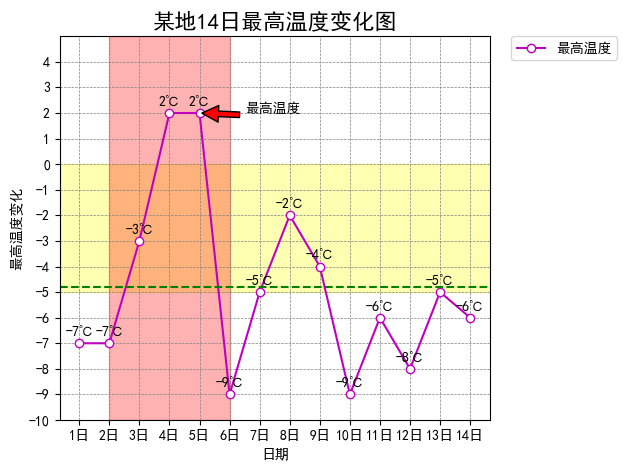

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei"]    # 解决中文乱码
plt.rcParams["axes.unicode_minus"] = False      # 解决负号不显示

df = pd.read_excel("../datas/天气.xlsx")  # 读取Excel文件 
x = df["日期"]  # x轴数据
y = df["最高温度"]  # y轴数据
plt.plot(x, y, color='m', linestyle='-', marker='o', mfc='w')

plt.xlabel("日期")  # 设置x轴标签
plt.ylabel("最高温度变化")

# 设置坐标轴和坐标刻度
plt.ylim(-10, 5)  # 设置y轴的范围
plt.yticks(range(-10, 5, 1))  # 设置y轴显示的刻度，本程序中默认显示间隔为2

# 添加文本标签
for a, b in zip(x, y):
    plt.text(a, b+0.2, '%.0f'%b+'℃', ha='center', va='bottom', fontsize=10)  # 在数据点上显示数值

# 设置标题和图例
plt.title("某地14日最高温度变化图", fontsize=16)  # 设置图表标题

# plt.legend(["最高温度"], loc='upper right', fontsize=10)        # 显示图例，图例右上角对齐（放在图的右上角）
plt.legend(["最高温度"], bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)  # 将图例左上角放在指定点

# 添加注释
plt.annotate("最高温度", 
             xy=(4, 2),         # 注释箭头指向的位置
             xytext=(5.5, 2),   # 注释文本的位置
             xycoords='data',   # 注释箭头指向的位置的坐标系
             arrowprops=dict(facecolor='r', shrink=0.05)    # 注释箭头样式
             )  # 添加注释

# 设置网格线
plt.grid(color='gray', linestyle='--', linewidth=0.5)  # 添加网格线，设置颜色、线型和线宽

# 绘制参考线
mean_temp = y.mean()  # 计算平均温度
plt.axhline(mean_temp, color='g', linestyle='--')  # 添加水平线，表示平均温度

# 选取范围
plt.axhspan(ymin=-5, ymax=0, color='yellow', alpha=0.3)  # 添加水平区域，表示温度在-5到0之间的范围
plt.axvspan(xmin=1, xmax=5, color='red', alpha=0.3)  # 添加垂直区域，表示特定日期范围

plt.tight_layout()  # 调整布局，避免标签重叠
plt.savefig("天气变化图.png", dpi=300)  # 保存图表为PNG文件，设置分辨率为300dpi

plt.show()  # 显示图表